Task 3

A car manufacturer wants to predict the fuel efficiency (miles per gallon, MPG) of its vehicles based on engine size, weight, and horsepower. You are tasked with building a Polynomial Regression model to capture non-linear relationships between features and MPG.

Dataset: Use the “Auto MPG” dataset from Kaggle (or a similar numeric dataset).

Dataset features:
    o	Cylinders → number of cylinders in the engine
    o	Displacement → engine displacement
    o	Horsepower → engine power
    o	Weight → vehicle weight
    o	Acceleration → time to accelerate from 0–60 mph
    o	Model Year → year of manufacture
    o	MPG → fuel efficiency (target variable)


1: Load Data

In [1]:
import pandas as pd

df = pd.read_csv("car_data.csv")
print(df.head())

   city_mpg                        class  combination_mpg  cylinders  \
0        25                  midsize car               29        4.0   
1        26                  midsize car               30        4.0   
2        25  small sport utility vehicle               27        4.0   
3        26  small sport utility vehicle               29        4.0   
4        26  small sport utility vehicle               28        4.0   

   displacement drive fuel_type  highway_mpg   make     model transmission  \
0           2.5   fwd       gas           36  mazda         6            m   
1           2.5   fwd       gas           37  mazda         6            a   
2           2.5   fwd       gas           31  mazda  cx-5 2wd            a   
3           2.0   fwd       gas           34  mazda  cx-5 2wd            m   
4           2.0   fwd       gas           32  mazda  cx-5 2wd            a   

   year  
0  2014  
1  2014  
2  2014  
3  2014  
4  2014  


2 Explore Data

2.1 Check Missing Values

In [2]:
print(df.isnull().sum())

city_mpg           0
class              0
combination_mpg    0
cylinders          2
displacement       2
drive              0
fuel_type          0
highway_mpg        0
make               0
model              0
transmission       0
year               0
dtype: int64


2.2 Fix Missing Values

In [4]:
df = df.fillna(df.mean(numeric_only=True))

2.3 Descriptive Statistics

In [5]:
print(df.describe())

         city_mpg  combination_mpg   cylinders  displacement  highway_mpg  \
count  550.000000       550.000000  550.000000    550.000000   550.000000   
mean    21.460000        24.069091    5.315693      2.931752    28.609091   
std      8.147392         7.478369    1.756790      1.246143     6.832228   
min     11.000000        14.000000    3.000000      1.200000    18.000000   
25%     17.000000        20.000000    4.000000      2.000000    24.000000   
50%     20.000000        23.000000    4.000000      2.500000    28.000000   
75%     24.000000        27.000000    6.000000      3.500000    32.000000   
max    126.000000       112.000000   12.000000      6.800000   102.000000   

              year  
count   550.000000  
mean   2019.000000  
std       3.165156  
min    2014.000000  
25%    2016.000000  
50%    2019.000000  
75%    2022.000000  
max    2024.000000  


2.4 Scatter Plots

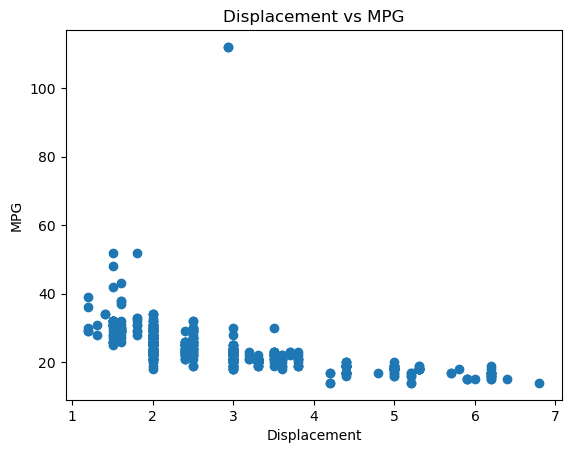

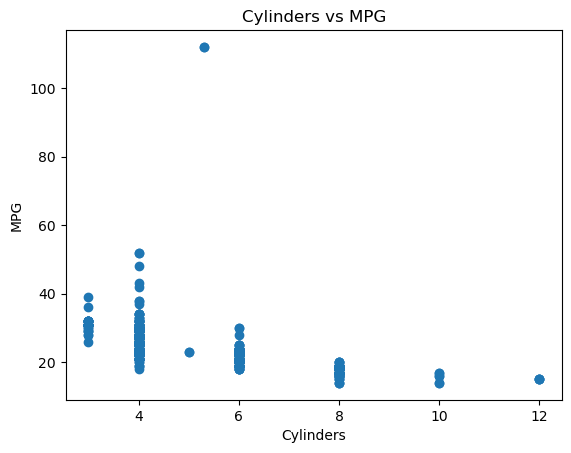

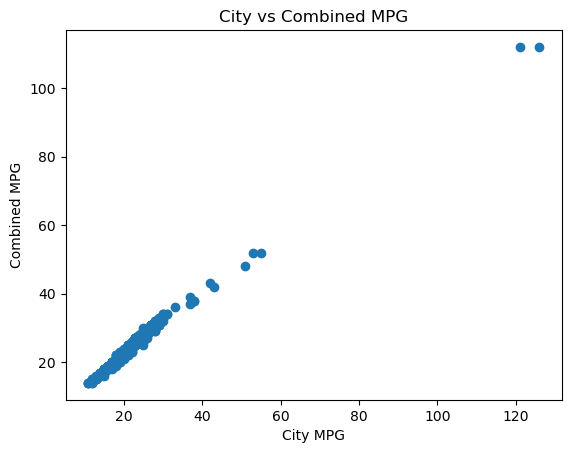

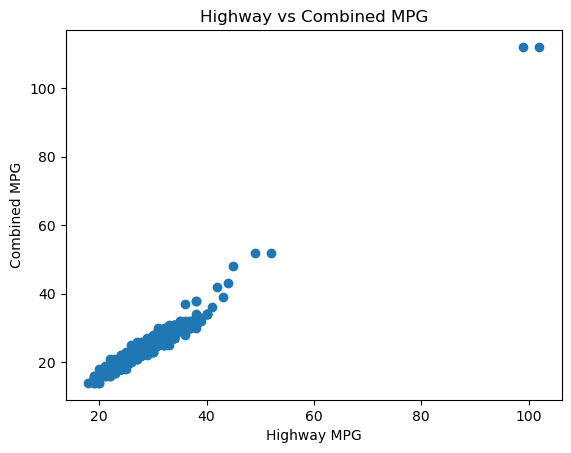

In [7]:
import matplotlib.pyplot as plt
plt.scatter(df["displacement"], df["combination_mpg"])
plt.xlabel("Displacement")
plt.ylabel("MPG")
plt.title("Displacement vs MPG")
plt.show()

plt.scatter(df["cylinders"], df["combination_mpg"])
plt.xlabel("Cylinders")
plt.ylabel("MPG")
plt.title("Cylinders vs MPG")
plt.show()

plt.scatter(df["city_mpg"], df["combination_mpg"])
plt.xlabel("City MPG")
plt.ylabel("Combined MPG")
plt.title("City vs Combined MPG")
plt.show()

plt.scatter(df["highway_mpg"], df["combination_mpg"])
plt.xlabel("Highway MPG")
plt.ylabel("Combined MPG")
plt.title("Highway vs Combined MPG")
plt.show()

3 Prepare Data

In [8]:
features = ["displacement", "cylinders", "city_mpg", "highway_mpg"]
X = df[features]

y = df["combination_mpg"]

4 Train-Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

5 Polynomial Transformation

In [10]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

6 Train Model

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

7 Evaluate

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test_poly)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 0.15414610050337627
R2 Score: 0.9940855166348798


8 Plot

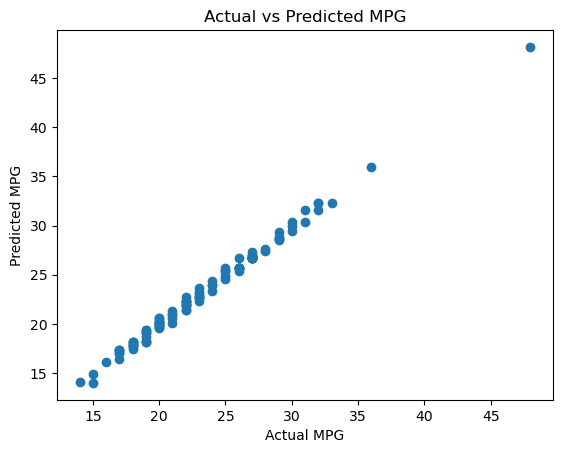

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")
plt.show()